# COCO-Mamba vs C.Origami

This notebook compares the two models on 1,224 GM12878 chromosome 7 windows. It reports distance-stratified PCC and per-window PCC, Spearman correlation, and PSNR. The embedded plots are retained from the completed evaluation.


In [1]:
import os

os.environ.setdefault('CUDA_VISIBLE_DEVICES', '0')

In [2]:
# COCO-Mamba versus reproduced C.Origami

import os
import glob
import pickle
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from scipy.stats import pearsonr
import torch.nn.functional as F
from tqdm import tqdm
import matplotlib.pyplot as plt
from pathlib import Path

# Check for mamba_ssm installation
try:
    from mamba_ssm import Mamba
except ImportError:
    print("="*80)
    print("ERROR: mamba-ssm is not installed. Please install it first:")
    print("pip install causal-conv1d>=1.0.0 mamba-ssm")
    print("="*80)
    raise

# ===================================================================
# 1. Model Architecture Definitions
# ===================================================================

# --- 1.1 COCO-Mamba V2 ---
class DownsampleBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride):
        super(DownsampleBlock, self).__init__()
        padding = kernel_size // 2
        self.block = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size, stride=stride, padding=padding),
            nn.BatchNorm1d(out_channels),
            nn.GELU()
        )
    def forward(self, x):
        return self.block(x)

class DeepFeatureResBlock(nn.Module):
    def __init__(self, channels, kernel_size=7):
        super().__init__()
        padding = (kernel_size - 1) // 2
        self.block = nn.Sequential(
            nn.Conv1d(channels, channels, kernel_size, stride=1, padding=padding),
            nn.BatchNorm1d(channels),
            nn.GELU(),
            nn.Conv1d(channels, channels, kernel_size, stride=1, padding=padding),
            nn.BatchNorm1d(channels),
        )
        self.activation = nn.GELU()
    def forward(self, x):
        return self.activation(x + self.block(x))

class HybridCNNMambaEncoder(nn.Module):
    def __init__(self, in_channels, d_model=128, num_cnn_blocks=3, num_mamba_layers=3, is_sequence=True):
        super().__init__()
        self.is_sequence = is_sequence
        if self.is_sequence:
            self.downsampler = nn.Sequential(
                DownsampleBlock(in_channels, 48, kernel_size=5, stride=5),
                DownsampleBlock(48, 96, kernel_size=5, stride=5),
                DownsampleBlock(96, d_model, kernel_size=5, stride=5),
                DownsampleBlock(d_model, d_model, kernel_size=5, stride=4),
                DownsampleBlock(d_model, d_model, kernel_size=5, stride=4)
            )
        else:
            self.downsampler = nn.Sequential(nn.Conv1d(in_channels, d_model, kernel_size=1), nn.GELU())
        self.cnn_feature_extractor = nn.Sequential(*[DeepFeatureResBlock(d_model) for _ in range(num_cnn_blocks)])
        self.mamba_layers = nn.ModuleList([Mamba(d_model=d_model, d_state=16, d_conv=4, expand=2) for _ in range(num_mamba_layers)])
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x):
        x = self.downsampler(x)
        x = self.cnn_feature_extractor(x)
        x = x.transpose(1, 2)
        x = self.norm(x)
        for mamba_layer in self.mamba_layers:
            x_fw = mamba_layer(x)
            x_rev = torch.flip(x, dims=[1])
            x_bw = mamba_layer(x_rev)
            x_bw = torch.flip(x_bw, dims=[1])
            x = x + x_fw + x_bw
        return x.transpose(1, 2)

class CrossAttentionFusion(nn.Module):
    def __init__(self, d_model, n_heads=4):
        super().__init__()
        self.omics_cross_attn = nn.MultiheadAttention(d_model, n_heads, batch_first=True)
        self.norm1 = nn.LayerNorm(d_model)
        self.seq_cross_attn = nn.MultiheadAttention(d_model, n_heads, batch_first=True)
        self.norm2 = nn.LayerNorm(d_model)
        self.fusion_conv = nn.Sequential(nn.Conv1d(d_model*2, d_model, 1), nn.BatchNorm1d(d_model), nn.GELU())

    def forward(self, seq_emb, omics_emb):
        seq_t, omics_t = seq_emb.transpose(1, 2), omics_emb.transpose(1, 2)
        omics_up, _ = self.omics_cross_attn(query=omics_t, key=seq_t, value=seq_t)
        omics_t = self.norm1(omics_t + omics_up)
        seq_up, _ = self.seq_cross_attn(query=seq_t, key=omics_t, value=omics_t)
        seq_t = self.norm2(seq_t + seq_up)
        combined = torch.cat([seq_t.transpose(1,2), omics_t.transpose(1,2)], dim=1)
        return self.fusion_conv(combined)

class ConvResBlock(nn.Module):
    def __init__(self, channels, kernel_size=3):
        super().__init__()
        padding = (kernel_size - 1) // 2
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, kernel_size, padding=padding), nn.BatchNorm2d(channels), nn.GELU(),
            nn.Conv2d(channels, channels, kernel_size, padding=padding), nn.BatchNorm2d(channels)
        )
        self.activation = nn.GELU()
    def forward(self, x):
        return self.activation(x + self.block(x))

class PracticalOuterProductDecoder(nn.Module):
    def __init__(self, in_channels=128, bottleneck_channels=16, num_blocks=4):
        super().__init__()
        self.bottleneck = nn.Conv1d(in_channels, bottleneck_channels, 1)
        self.initial_conv = nn.Conv2d(bottleneck_channels * 2, 64, 1)
        self.res_blocks = nn.Sequential(*[ConvResBlock(64) for _ in range(num_blocks)])
        self.final_conv = nn.Conv2d(64, 1, 3, padding=1)

    def forward(self, fused_embedding):
        bottleneck_emb = self.bottleneck(fused_embedding)
        B, C, L = bottleneck_emb.shape
        x1 = bottleneck_emb.unsqueeze(3).expand(-1,-1,L,L)
        x2 = bottleneck_emb.unsqueeze(2).expand(-1,-1,L,L)
        outer = torch.cat([x1, x2], dim=1)
        x = self.initial_conv(outer)
        x = self.res_blocks(x)
        x = self.final_conv(x)
        return (x + x.transpose(-2, -1)) / 2

class CNNMambaHybridModel_V2(nn.Module):
    def __init__(self, seq_in_channels=4, num_omics_features=4, d_model=128, fusion_out_dim=128,
                 num_cnn_blocks=3, num_mamba_layers=3, decoder_bottleneck_channels=16, decoder_num_blocks=4):
        super().__init__()
        print("Initializing COCO-Mamba V2 with cross-attention fusion")
        self.seq_encoder = HybridCNNMambaEncoder(in_channels=seq_in_channels, d_model=d_model, num_cnn_blocks=num_cnn_blocks, num_mamba_layers=num_mamba_layers)
        self.omics_encoder = HybridCNNMambaEncoder(in_channels=num_omics_features, d_model=d_model, num_cnn_blocks=num_cnn_blocks, num_mamba_layers=num_mamba_layers, is_sequence=False)
        self.fusion_module = CrossAttentionFusion(d_model=d_model)
        self.decoder = PracticalOuterProductDecoder(in_channels=fusion_out_dim, bottleneck_channels=decoder_bottleneck_channels, num_blocks=decoder_num_blocks)

    def forward(self, seq, omics):
        seq_emb = self.seq_encoder(seq)
        omics_emb = self.omics_encoder(omics)
        fused = self.fusion_module(seq_emb, omics_emb)
        pred = self.decoder(fused)
        return pred.squeeze(1)

# --- 1.2 Benchmark ReproducedConvModel ---
class ComparisonConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride=1):
        super(ComparisonConvBlock, self).__init__()
        padding = (kernel_size - 1) // 2
        self.scale = nn.Sequential(nn.Conv1d(in_channels, out_channels, kernel_size, stride=stride, padding=padding), nn.BatchNorm1d(out_channels), nn.ReLU())
        self.res = nn.Sequential(nn.Conv1d(out_channels, out_channels, kernel_size, padding=padding), nn.BatchNorm1d(out_channels), nn.ReLU(),
                                 nn.Conv1d(out_channels, out_channels, kernel_size, padding=padding), nn.BatchNorm1d(out_channels))
        self.relu = nn.ReLU()
    def forward(self, x):
        scaled = self.scale(x)
        return self.relu(self.res(scaled) + scaled)

class ComparisonResBlockDilated(nn.Module):
    def __init__(self, channels, kernel_size=3, dilation=2):
        super().__init__()
        padding = dilation * (kernel_size - 1) // 2
        self.res = nn.Sequential(nn.Conv2d(channels, channels, kernel_size, padding=padding, dilation=dilation), nn.BatchNorm2d(channels), nn.ReLU(),
                                 nn.Conv2d(channels, channels, kernel_size, padding=padding, dilation=dilation), nn.BatchNorm2d(channels))
        self.relu = nn.ReLU()
    def forward(self, x):
        return self.relu(self.res(x) + x)

class AdaptedEncoderSplit(nn.Module):
    def __init__(self, seq_in_channels, omics_in_channels, out_dim=128):
        super().__init__()
        self.seq_encoder = nn.Sequential(ComparisonConvBlock(seq_in_channels, 48, 5, 5), ComparisonConvBlock(48, 96, 5, 5),
                                         ComparisonConvBlock(96, 128, 5, 5), ComparisonConvBlock(128, 128, 5, 4),
                                         ComparisonConvBlock(128, out_dim, 5, 4))
        self.omics_encoder = nn.Sequential(ComparisonConvBlock(omics_in_channels, 64, 5, 1), ComparisonConvBlock(64, out_dim, 5, 1))
    def forward(self, seq_x, omics_x):
        return torch.cat([self.seq_encoder(seq_x), self.omics_encoder(omics_x)], dim=1)

class AdaptedDecoder(nn.Module):
    def __init__(self, in_channels, hidden=256, num_blocks=5, kernel_size=3):
        super().__init__()
        self.conv_start = nn.Sequential(nn.Conv2d(in_channels, hidden, 3, padding=1), nn.BatchNorm2d(hidden), nn.ReLU())
        self.res_blocks = nn.Sequential(*[ComparisonResBlockDilated(hidden, kernel_size, 2**i) for i in range(num_blocks)])
        self.conv_end = nn.Conv2d(hidden, 1, 1)
    def forward(self, x):
        return self.conv_end(self.res_blocks(self.conv_start(x)))

class ReproducedConvModel(nn.Module):
    def __init__(self, seq_in_channels, num_omics_features, encoder_out_dim=128, decoder_hidden_dim=128):
        super().__init__()
        self.encoder = AdaptedEncoderSplit(seq_in_channels, num_omics_features, encoder_out_dim)
        self.decoder = AdaptedDecoder(encoder_out_dim * 2 * 2, decoder_hidden_dim)
    def diagonalize(self, x):
        B, C, L = x.shape
        x_i = x.unsqueeze(2).repeat(1, 1, L, 1)
        x_j = x.unsqueeze(3).repeat(1, 1, 1, L)
        return torch.cat([x_i, x_j], dim=1)
    def forward(self, seq, omics):
        embedding = self.encoder(seq, omics)
        hic_map = self.diagonalize(embedding)
        pred = self.decoder(hic_map).squeeze(1)
        return (pred + pred.transpose(-2, -1)) / 2
from scipy.ndimage import gaussian_filter

# ===================================================================
# 2. Dataset Definition
# ===================================================================
class HiCDataAndOmicsDataset(Dataset):
    def __init__(self, pkl_files):
        self.file_paths = pkl_files
    def __len__(self):
        return len(self.file_paths)
    def __getitem__(self, idx):
        with open(self.file_paths[idx], 'rb') as f:
            data = pickle.load(f)
        sequence = torch.from_numpy(data['sequence_one_hot'].astype(np.float32))
        omics = torch.from_numpy(data['omics_signals'].astype(np.float32))
        hic = data['hic_matrix'].astype(np.float32)
        hic_log = np.log2(hic + 1)
        hic_log = gaussian_filter(hic_log, sigma=1)
        np.fill_diagonal(hic_log, 0)
        return sequence, omics, torch.from_numpy(hic_log)

# ===================================================================
# 3. Core Evaluation & Plotting Functions
# ===================================================================
def calculate_distance_pcc(model, dataloader, device, max_dist=512):
    model.eval()
    all_preds, all_reals = [], []
    with torch.no_grad():
        for seq, omics, hic in tqdm(dataloader, desc=f"Evaluating {model.__class__.__name__}", leave=False):
            seq, omics = seq.to(device), omics.to(device)
            with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
                pred = model(seq, omics)
            all_preds.append(pred.cpu().numpy())
            all_reals.append(hic.numpy())

    all_preds_np = np.concatenate(all_preds, axis=0)
    all_reals_np = np.concatenate(all_reals, axis=0)
    print(f"Collected predictions of shape: {all_preds_np.shape}")
    dist_corrs = []
    for d in tqdm(range(1, max_dist), desc="Calculating distance-PCC", leave=False):
        preds_diag = np.concatenate([np.diagonal(p, offset=d) for p in all_preds_np])
        reals_diag = np.concatenate([np.diagonal(r, offset=d) for r in all_reals_np])
        if np.std(preds_diag) == 0 or np.std(reals_diag) == 0:
            dist_corrs.append(np.nan)
        else:
            pcc, _ = pearsonr(preds_diag, reals_diag)
            dist_corrs.append(pcc)
    return dist_corrs

def plot_comparison(pcc_mamba_v2, pcc_cnn, output_path, max_dist_plot=500):
    distances = np.arange(1, len(pcc_mamba_v2) + 1)
    plt.style.use('seaborn-v0_8-whitegrid')
    plt.figure(figsize=(12, 8))
    
    plt.plot(distances[:max_dist_plot], pcc_mamba_v2[:max_dist_plot], 
             label='COCO-Mamba', color='crimson', linewidth=2.5)
    plt.plot(distances[:max_dist_plot], pcc_cnn[:max_dist_plot], 
             label='C.Origami', color='dodgerblue', linewidth=2.5, linestyle='--')
    
    plt.title('Model Performance on GM12878 chr7', fontsize=18, fontweight='bold')
    plt.xlabel('Genomic Distance (bp)', fontsize=14, fontweight='bold')
    plt.ylabel('Pearson Correlation (PCC)', fontsize=14, fontweight='bold')
    
    xtick_bins = np.array([0, 50, 100, 150, 200, 250, 300, 350, 400, 450, 500])
    xtick_labels = [f'{int(x * 2)}k' for x in xtick_bins]
    xtick_labels[0] = '0'
    plt.xticks(xtick_bins, xtick_labels, fontsize=12)
    plt.yticks(fontsize=12)
    
    # Show the full correlation range from zero.
    plt.ylim(bottom=0)
    plt.xlim(left=0, right=max_dist_plot)
    plt.legend(fontsize=14)
    plt.tight_layout()
    
    plt.savefig(output_path, dpi=300)
    print(f"\nComparison plot saved to: {output_path}")
    plt.close()

# ===================================================================
# 4. Main Execution
# ===================================================================


In [3]:
# Metric dependencies
import pandas as pd
import seaborn as sns
from scipy.stats import spearmanr
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

In [4]:
# Compute per-window image and correlation metrics.

def calculate_metrics_per_sample(model, dataloader, device):
    """
    Calculates PCC, Spearman, PSNR, and SSIM for each individual sample in the dataset.
    """
    model.eval()
    pcc_scores, spearman_scores, psnr_scores, ssim_scores = [], [], [], []
    
    with torch.no_grad():
        for seq, omics, hic in tqdm(dataloader, desc=f"Calculating all metrics for {model.__class__.__name__}", leave=False):
            seq, omics = seq.to(device), omics.to(device)
            with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
                preds = model(seq, omics)

            # Move data to CPU and convert to numpy for metric calculation
            preds_np = preds.cpu().numpy()
            reals_np = hic.numpy()

            # Iterate over each sample in the batch
            for i in range(preds_np.shape[0]):
                pred_sample = preds_np[i]
                real_sample = reals_np[i]
                
                # Flatten arrays for correlation calculations
                pred_flat = pred_sample.flatten()
                real_flat = real_sample.flatten()

                # 1. PCC (Pearson Correlation Coefficient)
                pcc, _ = pearsonr(pred_flat, real_flat)
                pcc_scores.append(pcc)

                # 2. Spearman Correlation
                spearman, _ = spearmanr(pred_flat, real_flat)
                spearman_scores.append(spearman)

                # Define data_range for PSNR and SSIM, which is crucial for normalized images
                data_range = max(real_sample.max(), pred_sample.max()) - min(real_sample.min(), pred_sample.min())

                # 3. PSNR (Peak Signal-to-Noise Ratio)
                psnr_val = psnr(real_sample, pred_sample, data_range=data_range)
                psnr_scores.append(psnr_val)
                
                # 4. SSIM (Structural Similarity Index)
                ssim_val = ssim(real_sample, pred_sample, data_range=data_range)
                ssim_scores.append(ssim_val)
                
    return pcc_scores, spearman_scores, psnr_scores, ssim_scores

In [6]:

# --- Configuration ---
# Set GM12878_DATA_DIR through the environment before running.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == '02_corigami_comparison':
    PROJECT_ROOT = PROJECT_ROOT.parent
GM12878_DATA_DIR = os.environ.get('GM12878_DATA_DIR')
if not GM12878_DATA_DIR:
    raise ValueError('Set GM12878_DATA_DIR to the GM12878 preprocessed .pkl directory.')
MAMBA_V2_MODEL_PATH = PROJECT_ROOT / 'checkpoints/benchmark/gm12878_mamba_v2_best_model_v2.pth'
CNN_MODEL_PATH = PROJECT_ROOT / 'checkpoints/benchmark/gm12878_reproduced_cnn_best_model.pth'

TARGET_CHROMOSOME = 'chr7'
BATCH_SIZE = 16
OUTPUT_PLOT_PATH = PROJECT_ROOT / '02_corigami_comparison' / f'02_distance_pcc_{TARGET_CHROMOSOME}.png'

# Model hyperparameters (must match training)
mamba_v2_params = {'d_model': 128, 'fusion_out_dim': 128, 'num_cnn_blocks': 3, 'num_mamba_layers': 3,
                    'decoder_bottleneck_channels': 48, 'decoder_num_blocks': 6}
cnn_params = {'encoder_out_dim': 128, 'decoder_hidden_dim': 256}
# ------------------

for path in [MAMBA_V2_MODEL_PATH, CNN_MODEL_PATH, Path(GM12878_DATA_DIR)]:
    if not path.exists():
        raise FileNotFoundError(f"Path not found: '{path}'")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 1. Load Data
print("\n--- Loading Data ---")
test_files = glob.glob(os.path.join(GM12878_DATA_DIR, f"*{TARGET_CHROMOSOME}*.pkl"))
if not test_files:
    raise FileNotFoundError(f"No .pkl files found for '{TARGET_CHROMOSOME}' in '{GM12878_DATA_DIR}'.")
print(f"Found {len(test_files)} test samples for {TARGET_CHROMOSOME}.")

with open(test_files[0], 'rb') as f:
    sample_data = pickle.load(f)
    num_omics = sample_data['omics_signals'].shape[0]
    hic_size = sample_data['hic_matrix'].shape[0]
    print(f"Detected {num_omics} omics features and Hi-C size {hic_size}x{hic_size}.")
    
test_dataset = HiCDataAndOmicsDataset(test_files)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

# 2. Evaluate COCO-Mamba V2
print("\n--- Evaluating CNN-Mamba Model V2 ---")
mamba_v2_model = CNNMambaHybridModel_V2(num_omics_features=num_omics, **mamba_v2_params).to(device)
mamba_v2_model.load_state_dict(torch.load(MAMBA_V2_MODEL_PATH, map_location=device))
pcc_vs_dist_mamba_v2 = calculate_distance_pcc(mamba_v2_model, test_loader, device, max_dist=hic_size)

# 3. Evaluate Benchmark CNN Model
print("\n--- Evaluating Benchmark CNN Model ---")
cnn_model = ReproducedConvModel(seq_in_channels=4, num_omics_features=num_omics, **cnn_params).to(device)
cnn_model.load_state_dict(torch.load(CNN_MODEL_PATH, map_location=device))
pcc_vs_dist_cnn = calculate_distance_pcc(cnn_model, test_loader, device, max_dist=hic_size)

# 4. Plot Comparison
print("\n--- Generating Comparison Plot ---")
plot_comparison(pcc_vs_dist_mamba_v2, pcc_vs_dist_cnn, OUTPUT_PLOT_PATH)
print("\n--- Calculating Sample-wise Metrics for Box Plots ---")
pcc_mamba, spearman_mamba, psnr_mamba, ssim_mamba = calculate_metrics_per_sample(mamba_v2_model, test_loader, device)
pcc_cnn, spearman_cnn, psnr_cnn, ssim_cnn = calculate_metrics_per_sample(cnn_model, test_loader, device)

# Store results in a dictionary for easy plotting
# This 'results' dictionary will be used in the cells below
results = {
    'PCC': {'COCO-Mamba': pcc_mamba, 'C.Origami': pcc_cnn},
    'Spearman': {'COCO-Mamba': spearman_mamba, 'C.Origami': spearman_cnn},
    'PSNR': {'COCO-Mamba': psnr_mamba, 'C.Origami': psnr_cnn},
    'SSIM': {'COCO-Mamba': ssim_mamba, 'C.Origami': ssim_cnn}
}
print("\nAll metrics calculated and stored in the 'results' dictionary.")

Using device: cuda

--- Loading Data ---
Found 1224 test samples for chr7.
Detected 4 omics features and Hi-C size 512x512.

--- Evaluating CNN-Mamba Model V2 ---
Initializing COCO-Mamba V2 with cross-attention fusion


Collected predictions of shape: (1224, 512, 512)



--- Evaluating Benchmark CNN Model ---


Collected predictions of shape: (1224, 512, 512)



--- Generating Comparison Plot ---

Comparison plot saved to: 02_corigami_comparison/02_distance_pcc_chr7.png

--- Calculating Sample-wise Metrics for Box Plots ---



All metrics calculated and stored in the 'results' dictionary.


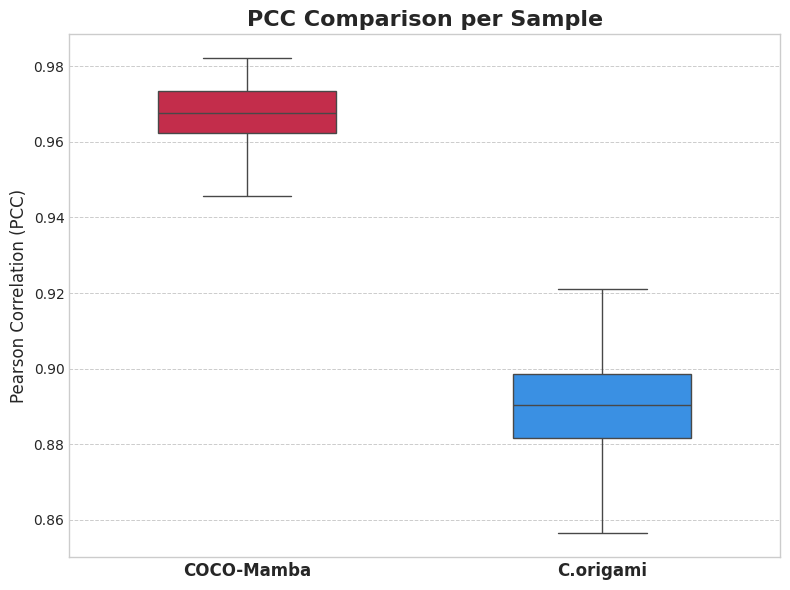

In [11]:
# Plot the saved metric distribution.

# Create DataFrame for PCC
pcc_df = pd.DataFrame(results['PCC'])

# Plot
plt.figure(figsize=(8, 6))
sns.boxplot(data=pcc_df, palette=['crimson', 'dodgerblue'], width=0.5, showfliers=False)
plt.title('PCC Comparison per Sample', fontsize=16, fontweight='bold')
plt.ylabel('Pearson Correlation (PCC)', fontsize=12)
plt.xticks(fontsize=12, fontweight='bold')
plt.grid(True, axis='y', linestyle='--', linewidth=0.7)
plt.tight_layout()
plt.show()

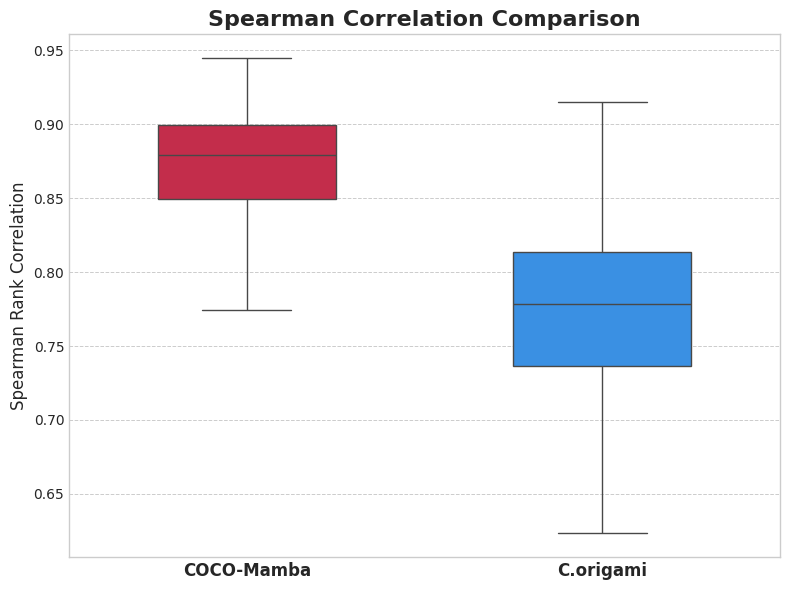

In [12]:
# Plot the saved metric distribution.

# Create DataFrame for Spearman
spearman_df = pd.DataFrame(results['Spearman'])

# Plot
plt.figure(figsize=(8, 6))
sns.boxplot(data=spearman_df, palette=['crimson', 'dodgerblue'], width=0.5, showfliers=False)
plt.title('Spearman Correlation Comparison', fontsize=16, fontweight='bold')
plt.ylabel('Spearman Rank Correlation', fontsize=12)
plt.xticks(fontsize=12, fontweight='bold')
plt.grid(True, axis='y', linestyle='--', linewidth=0.7)
plt.tight_layout()
plt.show()

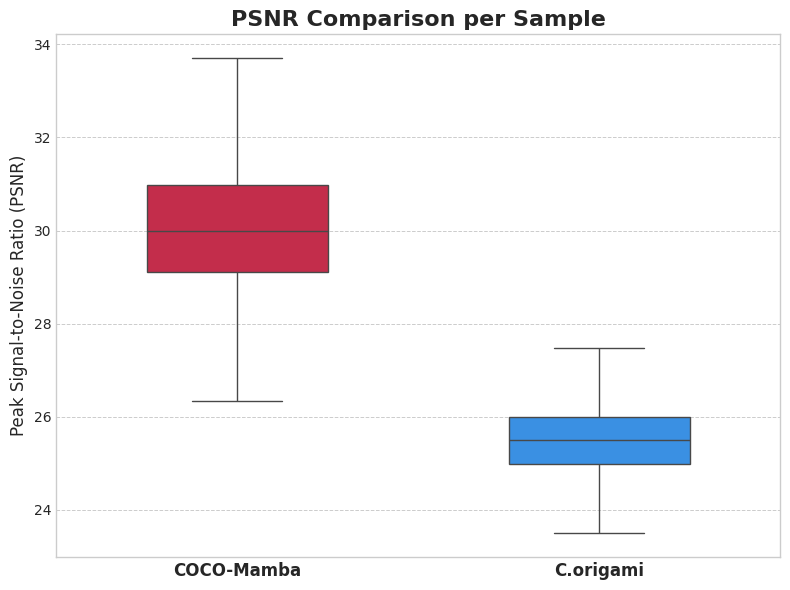

In [13]:
# Plot the saved metric distribution.

# Create DataFrame for PSNR
psnr_df = pd.DataFrame(results['PSNR'])

# Plot
plt.figure(figsize=(8, 6))
sns.boxplot(data=psnr_df, palette=['crimson', 'dodgerblue'], width=0.5, showfliers=False)
plt.title('PSNR Comparison per Sample', fontsize=16, fontweight='bold')
plt.ylabel('Peak Signal-to-Noise Ratio (PSNR)', fontsize=12)
plt.xticks(fontsize=12, fontweight='bold')
plt.grid(True, axis='y', linestyle='--', linewidth=0.7)
plt.tight_layout()
plt.show()